In [161]:
#Importing required libraries:

#Plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.lines import Line2D
import seaborn as sns
import matplotlib._color_data as mcd


#Word processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import regex
import unidecode
import spacy

#
import numpy as np
from numpy import unique
from numpy import where
import pandas as pd
from pandarallel import pandarallel
from tqdm import tqdm
tqdm.pandas(desc="progress-bar")

#Doc2vec
import gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

#sklearn
import sklearn
from sklearn import preprocessing
from sklearn import metrics
from sklearn.manifold import TSNE

#Cluster Algorithm
import hdbscan
from joblib import Memory
mem = Memory(cachedir='/Users/diego/development/untref/tesis/tesis-ml/joblib')


/Users/diego/opt/anaconda3/envs/hands-on-ml/lib/python3.7/site-packages/tqdm/std.py:697: FutureWarning: The Panel class is removed from pandas. Accessing it from the top-level namespace will also be removed in the next version
  from pandas import Panel
/Users/diego/opt/anaconda3/envs/hands-on-ml/lib/python3.7/site-packages/ipykernel_launcher.py:41: DeprecationWarning: The 'cachedir' parameter has been deprecated in version 0.12 and will be removed in version 0.14.
You provided "cachedir='/Users/diego/development/untref/tesis/tesis-ml/joblib'", use "location='/Users/diego/development/untref/tesis/tesis-ml/joblib'" instead.


In [2]:
#
!spacy download es_core_news_sm
nlp = spacy.load('es_core_news_sm')

#Installing required dictionaries
nltk.download('stopwords')
my_stop_words = stopwords.words('spanish')
my_stop_words.extend([',','.','!','#'])

✔ Download and installation successful
You can now load the model via spacy.load('es_core_news_sm')


[nltk_data] Downloading package stopwords to /Users/diego/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
def do_lemmatizing(word):
    result = word
    if len(word) > 0:
        doc = nlp(word)
        lemma = [tok.lemma_.lower() for tok in doc]
        result = lemma[0]
    return result

In [4]:
def do_text_cleaning(tweet_text, replace_screen_names, common_words_array):
    # split the string on whitespace
    out = tweet_text.split(" ")
    
    # identify urls
    # replace with URL
    out = ['URL' if bool(regex.search("http[s]?://", i)) else i for i in out]
    
    # identify screen names
    # replace with SCREENNAME
    if replace_screen_names :  out = ['SCREENNAME' if i.startswith('@') else i for i in out]

    # remove all punctuation
    out = [regex.sub("[^\\w\\s]|\n", "", i) for i in out]
    
    # remove all numerics
    out = [regex.sub("^[0-9]*$", "", i) for i in out]
    
    # make all non-keywords lowercase
    keys = ['SCREENNAME', 'URL']
    out = [i.lower() if i not in keys else i for i in out]
    
    # remove keywords
    out = [i for i in out if i not in keys]
    
    # Remove stopwords
    out = [i for i in out if i not in my_stop_words]
    
    # Remove known hashtags/common words
    out = [i for i in out if i not in common_words_array]
    
    # lemmatizing
    out = [do_lemmatizing(i) for i in out]
    
    #remove accents
    out = [unidecode.unidecode(i) for i in out]
    
    # keep words 5 or more characters long
    out = [i for i in out if len(i) >= 5]
    
    return out

In [5]:
def tsne(tweet_datafame):
    model_tsne = TSNE(random_state=42, verbose=1, perplexity=35, learning_rate=500, n_iter=5000, n_jobs=-1)
    tweets_tsne = model_tsne.fit_transform(tweet_datafame)
    return(tweets_tsne)

In [159]:
def plot_with_details(model, labels, tnse_data):
    #setup colors
    colors = list(mcd.XKCD_COLORS.values())[:len(unique(labels))]
    # retrieve unique clusters
    clusters = unique(labels)
    #Setup Plot
    plt.figure(figsize=(15, 10))
    plot_title = str(model)
    plt.title(plot_title)
    label_names = []
    # create scatter plot for samples from each cluster
    for idx, cluster in enumerate(clusters):
        # get row indexes for samples with this cluster
        selections = tnse_data[where(labels == cluster)]
        if(cluster == -1):
            label_names.append("Noise")
        else:
            label_names.append("Cluster " + str(cluster))
        # create scatter of these samples
        #plt.scatter(selections[:,0], selections[:,1], alpha=0.2, s=5, label=label, c=colors[idx]);
        plt.scatter(selections[:,0], selections[:,1], alpha=0.2, s=5, c=colors[idx]);
    #Legend
    #legend_elements = [Line2D([0], [0], marker='o', color='w', label='Cluster {}'.format(i+1),
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=label_names[i],
               markerfacecolor=mcolor, markersize=5) for i, mcolor in enumerate(colors)]
    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc=2)
    #plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize='large')
    # show the plot
    filename = str(model) + "-details.png"
    plt.savefig("cluster-comp.png") 
    plt.show()  

In [23]:
def plot_sbn(model, labels, tnse_data):
    color_palette = sns.color_palette('deep', len(labels))
    cluster_colors = [color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in labels]
    cluster_member_colors = [sns.desaturate(x, p) for x, p in
                         zip(cluster_colors, model.probabilities_)]
    unique_clusters = unique(labels)
    unique_color_palette = sns.color_palette('deep', len(unique_clusters))
    unique_cluster_colors = [unique_color_palette[x] if x >= 0
                  else (0.5, 0.5, 0.5)
                  for x in unique_clusters]
    plt.figure(figsize=(15, 10))
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Cluster {}'.format(i+1), 
               markerfacecolor=mcolor, markersize=5) for i, mcolor in enumerate(unique_cluster_colors)]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.scatter(tnse_data[:,0], tnse_data[:,1], s=50, linewidth=0, c=cluster_member_colors, alpha=0.25)

In [26]:
def condensed_tree_plot(model, labels):
    plt.figure(figsize=(20, 10))
    color_palette = sns.color_palette('deep', len(labels))
    model.condensed_tree_.plot(select_clusters=True,
                               selection_palette=color_palette)

In [7]:
#Loading Tweets
csv_path = '/Users/diego/development/untref/tesis/export_no_rt_20210125.csv'
original_tweet_data = pd.read_csv(csv_path, sep=';')

In [8]:
#Making a working copy
tweet_data = original_tweet_data.copy()

In [9]:
# Cleaning text
common_words_array = ["debatepresidencial","debate", "debatepresidencial2019", "debatear2019"]
replace_screen_names = False
#parallel
pandarallel.initialize(progress_bar=True)
tweet_data['Text'] = tweet_data['Text'].parallel_apply(do_text_cleaning, args=(replace_screen_names, common_words_array))

INFO: Pandarallel will run on 4 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [11]:
#Converting to list
tweet_text_list = tweet_data['Text'].to_list()

In [12]:
# Convert tokenized document into gensim formated tagged data
tagged_data = [TaggedDocument(d, [i]) for i, d in enumerate(tweet_text_list)]
tagged_data_size = len(tweet_text_list)

In [14]:
# Create Doc2Vec model
model = Doc2Vec(vector_size=100, dbow_words= 1, dm=0, epochs=1, window=5, seed=42, min_count=5, workers=4, alpha=0.025, min_alpha=0.025)

# Build a vocabulary
model.build_vocab(tagged_data)

# Train the model
for epoch in range(10):
    print("epoch "+str(epoch))
    model.train(tagged_data, total_examples=tagged_data_size, epochs=1)
    model.save('tweet_doc2vec.model')
    model.alpha -= 0.002  # decrease the learning rate
    model.min_alpha = model.alpha  # fix the learning rate, no decay

epoch 0
epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9


In [ ]:
## Load saved doc2vec model
model = Doc2Vec.load("test_doc2vec.model")

In [15]:
# Keeping just the columns I want
df = tweet_data.copy()
del df['Tweet ID']
del df['Parent Tweet ID']
del df['Creation Date']
del df['User Name']
del df['User ScreenName']
del df['Text']
del df['DB ID']
#Normalization
for column_name in ['Retweet Count', 'Fav Count', 'User Followers']:
    df[column_name] = 2*(df[column_name]-np.min(df[column_name])) / (np.max(df[column_name])-np.min(df[column_name]))-1
df['Tweet From Verified Account'] = df['Tweet From Verified Account'].map({True: 1, False: -1})
df['User Has Default Profile Image'] = df['User Has Default Profile Image'].map({True: 1, False: -1})

In [16]:
#Adding doc2vec results
new_df = pd.DataFrame(data=model.docvecs.vectors_docs)

joined = df.join(new_df)

In [18]:
#TSNE
tnse_data = tsne(joined)

[t-SNE] Computing 106 nearest neighbors...
[t-SNE] Indexed 87459 samples in 24.371s...
[t-SNE] Computed neighbors for 87459 samples in 958.244s...
[t-SNE] Computed conditional probabilities for sample 1000 / 87459
[t-SNE] Computed conditional probabilities for sample 2000 / 87459
[t-SNE] Computed conditional probabilities for sample 3000 / 87459
[t-SNE] Computed conditional probabilities for sample 4000 / 87459
[t-SNE] Computed conditional probabilities for sample 5000 / 87459
[t-SNE] Computed conditional probabilities for sample 6000 / 87459
[t-SNE] Computed conditional probabilities for sample 7000 / 87459
[t-SNE] Computed conditional probabilities for sample 8000 / 87459
[t-SNE] Computed conditional probabilities for sample 9000 / 87459
[t-SNE] Computed conditional probabilities for sample 10000 / 87459
[t-SNE] Computed conditional probabilities for sample 11000 / 87459
[t-SNE] Computed conditional probabilities for sample 12000 / 87459
[t-SNE] Computed conditional probabilities for

In [189]:
#HDBSCAN Clustering
model = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=5, memory=mem)
#model = hdbscan.HDBSCAN(metric='haversine', min_cluster_size=3, algorithm='prims_balltree', core_dist_n_jobs=8, memory=mem)
labels = model.fit_predict(joined)

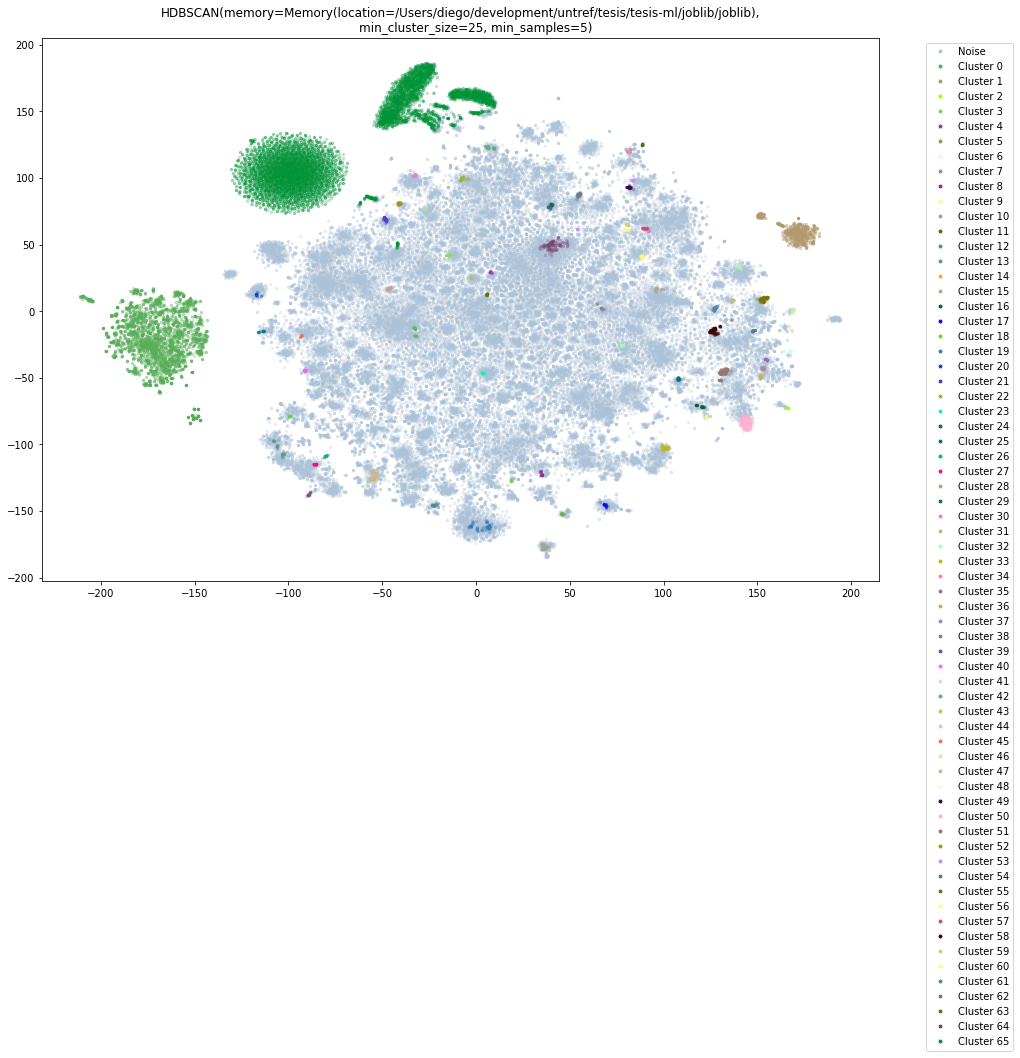

In [190]:
#Ploting results
plot_with_details(model, labels, tnse_data)

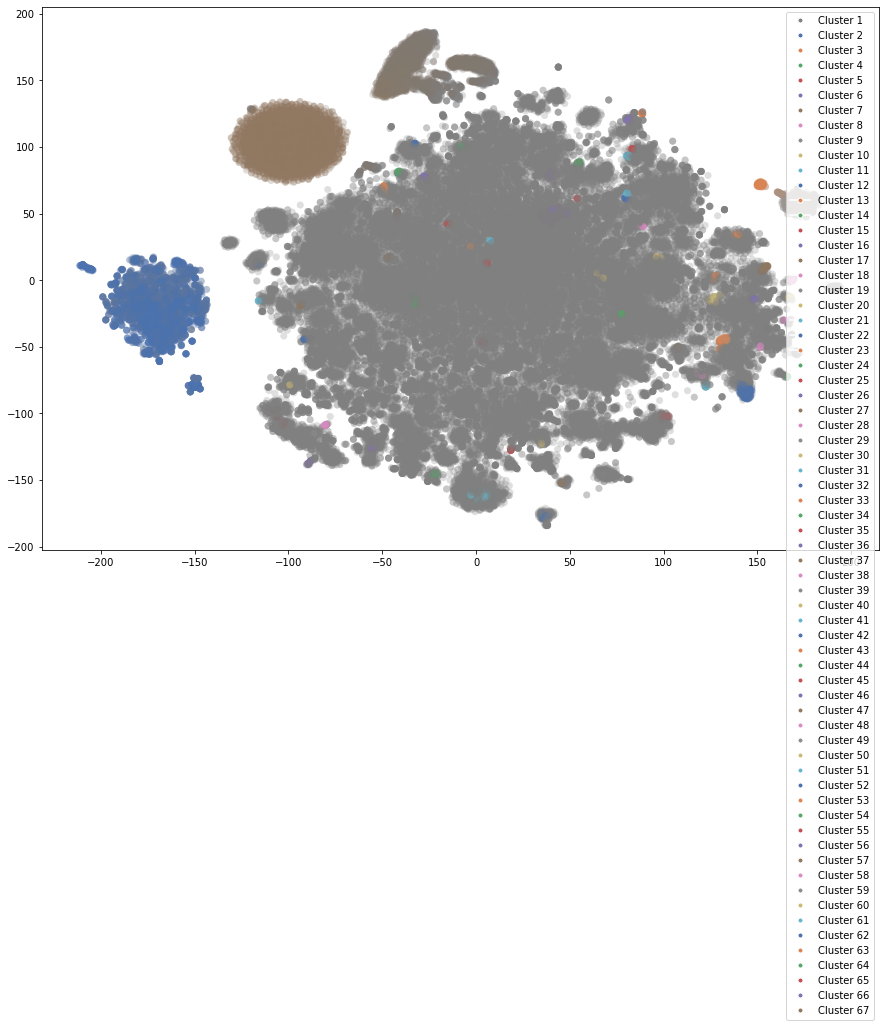

In [193]:
plot_sbn(model, labels, tnse_data)

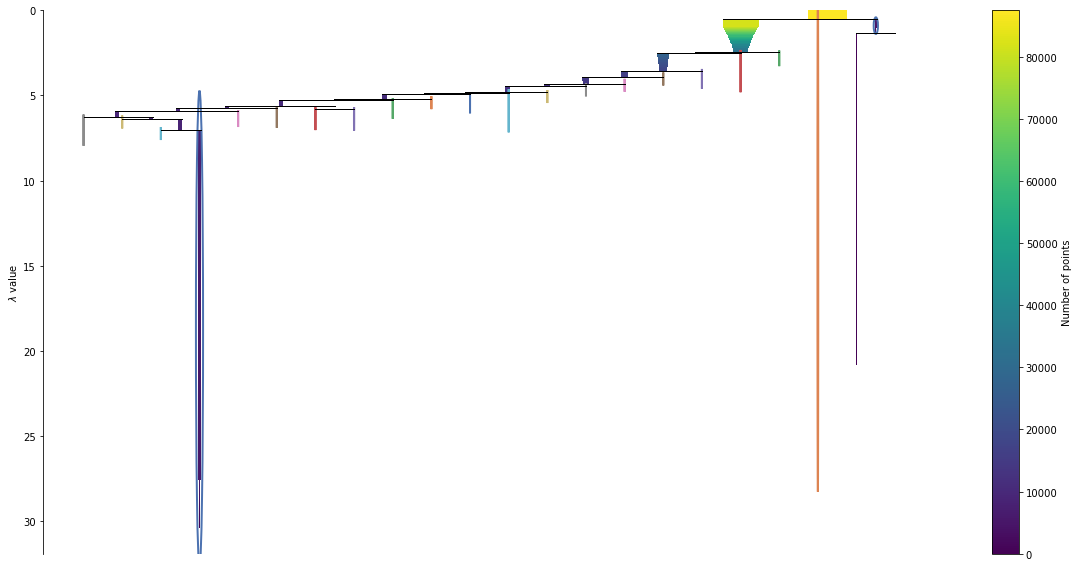

In [136]:
condensed_tree_plot(model, labels)

In [152]:
labels

array([-1,  5, -1, ...,  0, -1, -1])

In [192]:
model.plot

AttributeError: 'HDBSCAN' object has no attribute 'plot'